In [140]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field
import operator

In [141]:
import os
from dotenv import load_dotenv
load_dotenv()
from openai import OpenAI
from langchain_groq import ChatGroq

model = ChatGroq( model="openai/gpt-oss-20b", api_key=os.environ.get("GROQ_API_KEY"))

In [142]:
class EvaluationSchema(BaseModel):
    feedback:str = Field(description="Detailed Feedback for the given Essay")
    score:int = Field(description="Score out of 10",ge=0,le=10)

In [161]:
structured_model = model.with_structured_output(EvaluationSchema)

structured_model.invoke("""The ongoing conflict between the United States, Israel, and Iran has reached a critical and unprecedented stage in early 2026. Following years of "shadow warfare" and proxy battles, the situation escalated into a direct, high-intensity kinetic war—often referred to as the 2026 Iran War—which began on February 28, 2026.The current state of the conflict can be summarized by three distinct fronts: the initial decapitation strikes, the regional retaliatory spiral, and the global economic fallout.1. The Catalyst: Operation Epic FuryOn February 28, 2026, the United States and Israel launched a massive, coordinated surprise offensive dubbed Operation Epic Fury (U.S.) and Roaring Lion (Israel).The Targets: The strikes utilized nearly 900 assets in the first 12 hours, targeting Iranian nuclear facilities, ballistic missile sites, and high-level leadership.Leadership Decapitation: A primary objective was achieved in the opening wave when a strike in Tehran killed Iran’s Supreme Leader, Ali Khamenei. Other senior officials, including Ali Larijani, were also killed in subsequent weeks.Justification: The Trump administration and the Netanyahu government cited the imminent threat of a nuclear-armed Iran and the failure of 2025–2026 diplomatic efforts as the rationale for the preemptive strike.2. The Retaliatory Spiral (March 2026)Following the death of Ali Khamenei, Iran appointed his son, Mojtaba Khamenei, as the new Supreme Leader. Iran’s response has been a strategy of "horizontal escalation," widening the war to include U.S. allies and global infrastructure.Missile Barrages: Iran has launched over 400 ballistic missiles and thousands of drones toward Israel. While Israeli defense systems (Iron Dome, Arrow) have intercepted roughly 92% of these, recent strikes in March 2026 have hit civilian areas in Arad and near the Dimona nuclear facility.Attacks on U.S. Bases: Iranian proxies and direct IRGC strikes have targeted U.S. military installations in Bahrain, Qatar, Kuwait, and the UAE. At least 13 U.S. service members have been reported killed as of late March.The Maritime Front: Iran has effectively closed the Strait of Hormuz, a chokepoint through which 20% of the world’s oil passes. This has led to the stranding of hundreds of vessels and direct attacks on energy infrastructure, such as refineries in Kuwait and the UAE.3. Current Regional & Global ImpactsThe conflict has moved beyond a three-way struggle, pulling in various regional actors and affecting the global economy.Lebanon Front: The 2026 Lebanon War has ignited simultaneously, with Israel conducting heavy strikes against Hezbollah to prevent a northern ground invasion.Economic Shock: The closure of the Strait of Hormuz has caused global oil prices to skyrocket, leading to fuel rationing in parts of Asia and high volatility in Western stock markets.Humanitarian Crisis: In less than a month, the death toll has exceeded 3,000 in Iran and over 1,000 in Lebanon. Displacement is widespread, with millions fleeing combat zones in the Middle East.Summary of Current Status (as of March 22, 2026)CategoryStatusU.S. PositionIntensifying strikes while simultaneously signaling a desire to "wind down" if terms are met.Israel PositionVowing to "remove existential threats" permanently; continuing strikes on Iranian and Hezbollah targets.Iran PositionTransitioning under new leadership (Mojtaba Khamenei); threatening global tourist and energy infrastructure.Global ImpactMassive oil supply disruption; U.K. and other NATO allies providing defensive support in the Gulf.The conflict remains highly volatile. While there have been occasional mentions of a ceasefire by various intermediaries, the current stance from Washington and Jerusalem suggests a determination to continue until Iran's military and nuclear capabilities are decisively degraded.""").feedback

'The essay provides a comprehensive, chronologically organized overview of a complex geopolitical conflict, with clear delineation of three main fronts and a concise status summary. Strengths include vivid detail of military operations, the inclusion of specific dates, and the use of quantitative data (e.g., number of assets, missile strikes, casualty figures). The narrative effectively conveys the escalation from covert to kinetic warfare and highlights the multi‑front nature of the crisis. However, the essay could benefit from a more balanced perspective; it largely presents U.S. and Israeli actions as justified while offering limited insight into Iranian motives beyond retaliation. Some statements (e.g., the death tolls, claims of “decapitation strikes”) would be strengthened by citing sources or acknowledging uncertainty. Additionally, the analysis of global impacts is somewhat brief compared to the operational details, and the conclusion could synthesize the implications for inter

In [144]:
class EssayState(TypedDict):
    essay:str 
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str
    individual_scores: Annotated[list[int],operator.add]
    avg_score:float

In [145]:
def evaluate_lang(state: EssayState):
    essay = state["essay"]

    prompt = f"""
    json
You are an expert English language evaluator.

Evaluate ONLY the LANGUAGE QUALITY of this essay:

\"\"\"{essay}\"\"\"

"""

    result= structured_model.invoke(prompt)

    language_feedback = result.feedback
    score = result.score


    return {
        "language_feedback": language_feedback,
        "individual_scores": [score]
    }

In [146]:
def essay_analysis(state: EssayState):
    essay = state["essay"]

    prompt = f"""
    json
You are an expert essay evaluator.

Analyze ONLY the *content quality and depth of analysis* in the essay below.
Focus strictly on:
- strength of arguments
- depth of explanation
- use of evidence or reasoning
- relevance to the topic
- logical flow and insight

Essay:
\"\"\"{essay}\"\"\"
"""

    # This will automatically return EvaluationSchema
    result = structured_model.invoke(prompt)

    analysis_feedback = result.feedback
    score = result.score



    return {
        "analysis_feedback": analysis_feedback,
        "individual_scores":[score]
    }

In [147]:
def evaluate_clarity(state: EssayState):
    essay = state["essay"]

    prompt = f"""
    json
You are an expert essay evaluator.

Evaluate ONLY the *clarity and readability* of the essay below.
Focus strictly on:
- how easily the ideas can be understood
- organization and logical flow
- sentence simplicity vs complexity
- removal of ambiguity
- overall readability

Essay:
\"\"\"{essay}\"\"\"
"""

    # structured_model returns EvaluationSchema automatically
    result = structured_model.invoke(prompt)

    clarity_feedback = result.feedback
    score = result.score



    return {
        "clarity_feedback": clarity_feedback,
        "individual_scores": [score]
    }

In [148]:
def final_evaluation(state: EssayState):
    language_feedback = state.get("language_feedback", "")
    analysis_feedback = state.get("analysis_feedback", "")
    clarity_feedback = state.get("clarity_feedback", "")
    individual_scores = state.get("individual_scores", [])

    # Compute average score
    avg_score = sum(individual_scores) / len(individual_scores) if individual_scores else 0

    # Prepare prompt for generating final overall feedback
    prompt = f"""
json
You are an expert essay evaluator.

Based on the following category-wise feedback:

Language Quality Feedback:
{language_feedback}

Analysis Feedback:
{analysis_feedback}

Clarity Feedback:
{clarity_feedback}

And the average score of {avg_score:.2f} out of 10,

Provide a single well-structured paragraph of overall feedback summarizing:
- the essay’s strengths
- major weaknesses
- areas of improvement
- final impression on quality

Keep it concise, balanced, and professional.
"""

    # Reuse the same structured model OR a normal model depending on your design.
    # Here we want plain text, so no schema is required.
    overall_feedback = model.invoke(prompt).content

    return {
        "overall_feedback": overall_feedback,
        "avg_score": avg_score
    }

In [149]:
graph = StateGraph(EssayState)

# Add nodes
graph.add_node("evaluate_lang", evaluate_lang)
graph.add_node("essay_analysis", essay_analysis)
graph.add_node("evaluate_clarity", evaluate_clarity)
graph.add_node("final_evaluation", final_evaluation)

# START → all three nodes
graph.add_edge(START, "evaluate_lang")
graph.add_edge(START, "essay_analysis")
graph.add_edge(START, "evaluate_clarity")

# All three → final_evaluation
graph.add_edge("evaluate_lang", "final_evaluation")
graph.add_edge("essay_analysis", "final_evaluation")
graph.add_edge("evaluate_clarity", "final_evaluation")

# final → END
graph.add_edge("final_evaluation", END)

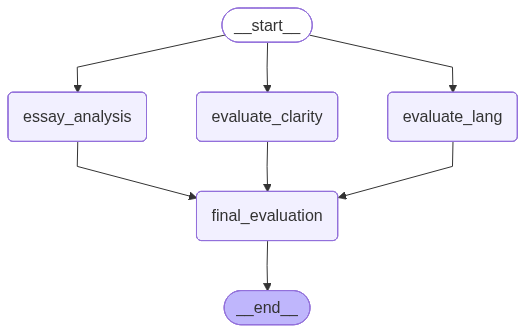

In [150]:
# compile

workflow = graph.compile()
workflow

In [151]:
initial_state = {
    "essay": """
The ongoing conflict between the United States, Israel, and Iran has reached a critical and unprecedented stage in early 2026. Following years of "shadow warfare" and proxy battles, the situation escalated into a direct, high-intensity kinetic war—often referred to as the 2026 Iran War—which began on February 28, 2026.The current state of the conflict can be summarized by three distinct fronts: the initial decapitation strikes, the regional retaliatory spiral, and the global economic fallout.1. The Catalyst: Operation Epic FuryOn February 28, 2026, the United States and Israel launched a massive, coordinated surprise offensive dubbed Operation Epic Fury (U.S.) and Roaring Lion (Israel).The Targets: The strikes utilized nearly 900 assets in the first 12 hours, targeting Iranian nuclear facilities, ballistic missile sites, and high-level leadership.Leadership Decapitation: A primary objective was achieved in the opening wave when a strike in Tehran killed Iran’s Supreme Leader, Ali Khamenei. Other senior officials, including Ali Larijani, were also killed in subsequent weeks.Justification: The Trump administration and the Netanyahu government cited the imminent threat of a nuclear-armed Iran and the failure of 2025–2026 diplomatic efforts as the rationale for the preemptive strike.2. The Retaliatory Spiral (March 2026)Following the death of Ali Khamenei, Iran appointed his son, Mojtaba Khamenei, as the new Supreme Leader. Iran’s response has been a strategy of "horizontal escalation," widening the war to include U.S. allies and global infrastructure.Missile Barrages: Iran has launched over 400 ballistic missiles and thousands of drones toward Israel. While Israeli defense systems (Iron Dome, Arrow) have intercepted roughly 92% of these, recent strikes in March 2026 have hit civilian areas in Arad and near the Dimona nuclear facility.Attacks on U.S. Bases: Iranian proxies and direct IRGC strikes have targeted U.S. military installations in Bahrain, Qatar, Kuwait, and the UAE. At least 13 U.S. service members have been reported killed as of late March.The Maritime Front: Iran has effectively closed the Strait of Hormuz, a chokepoint through which 20% of the world’s oil passes. This has led to the stranding of hundreds of vessels and direct attacks on energy infrastructure, such as refineries in Kuwait and the UAE.3. Current Regional & Global ImpactsThe conflict has moved beyond a three-way struggle, pulling in various regional actors and affecting the global economy.Lebanon Front: The 2026 Lebanon War has ignited simultaneously, with Israel conducting heavy strikes against Hezbollah to prevent a northern ground invasion.Economic Shock: The closure of the Strait of Hormuz has caused global oil prices to skyrocket, leading to fuel rationing in parts of Asia and high volatility in Western stock markets.Humanitarian Crisis: In less than a month, the death toll has exceeded 3,000 in Iran and over 1,000 in Lebanon. Displacement is widespread, with millions fleeing combat zones in the Middle East.Summary of Current Status (as of March 22, 2026)CategoryStatusU.S. PositionIntensifying strikes while simultaneously signaling a desire to "wind down" if terms are met.Israel PositionVowing to "remove existential threats" permanently; continuing strikes on Iranian and Hezbollah targets.Iran PositionTransitioning under new leadership (Mojtaba Khamenei); threatening global tourist and energy infrastructure.Global ImpactMassive oil supply disruption; U.K. and other NATO allies providing defensive support in the Gulf.The conflict remains highly volatile. While there have been occasional mentions of a ceasefire by various intermediaries, the current stance from Washington and Jerusalem suggests a determination to continue until Iran's military and nuclear capabilities are decisively degraded.
"""
}

In [152]:
result = workflow.invoke(initial_state)
print(result)

{'essay': '\nThe ongoing conflict between the United States, Israel, and Iran has reached a critical and unprecedented stage in early 2026. Following years of "shadow warfare" and proxy battles, the situation escalated into a direct, high-intensity kinetic war—often referred to as the 2026 Iran War—which began on February 28, 2026.The current state of the conflict can be summarized by three distinct fronts: the initial decapitation strikes, the regional retaliatory spiral, and the global economic fallout.1. The Catalyst: Operation Epic FuryOn February 28, 2026, the United States and Israel launched a massive, coordinated surprise offensive dubbed Operation Epic Fury (U.S.) and Roaring Lion (Israel).The Targets: The strikes utilized nearly 900 assets in the first 12 hours, targeting Iranian nuclear facilities, ballistic missile sites, and high-level leadership.Leadership Decapitation: A primary objective was achieved in the opening wave when a strike in Tehran killed Iran’s Supreme Lead